In [1]:
# ==========================================
# CELDA 1: Configuración e Importación de Librerías
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import scipy
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib
import os
import re

# Configuración visual y semilla aleatoria para reproducibilidad
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

print("Librerías importadas correctamente. Entorno listo.")

Librerías importadas correctamente. Entorno listo.


In [2]:
# ==========================================
# CELDA 2: Generación de Dataset Sintético y Limpieza
# ==========================================

# 1. Definición de intenciones por nivel de urgencia
textos_alta = [
    "urgente amparo contra desalojo inminente", 
    "habeas corpus por detencion arbitraria", 
    "medida cautelar por violencia familiar urgente",
    "peligro de fuga solicito impedimento de salida",
    "queja por retraso en orden de liberacion"
]

textos_media = [
    "presento apelacion de sentencia civil", 
    "deseo saber el estado de mi expediente laboral", 
    "ingreso de demanda por alimentos",
    "solicitud de sucesion intestada",
    "presentacion de peritaje contable judicial"
]

textos_baja = [
    "consulta sobre horario de atencion en mesa de partes", 
    "requisitos para solicitar copias certificadas", 
    "como restablecer mi contraseña del sistema",
    "direccion de la corte superior",
    "costo de arancel judicial para exhorto"
]

# 2. Generacion de 300 registros balanceados
datos = []
for clase, textos in zip(['Alta', 'Media', 'Baja'], [textos_alta, textos_media, textos_baja]):
    muestras = np.random.choice(textos, size=100, replace=True)
    for texto in muestras:
        # Añadimos una pequeña variabilidad al final del texto
        texto_ruido = texto + " " + "".join(np.random.choice(list("abcdefgh"), size=np.random.randint(0, 3)))
        datos.append({'consulta': texto_ruido.strip(), 'urgencia': clase})

df_cejbot = pd.DataFrame(datos)
df_cejbot = df_cejbot.sample(frac=1, random_state=42).reset_index(drop=True)

# 3. Inyección de nulos para pruebas de robustez y posterior limpieza
indices_nulos = np.random.choice(df_cejbot.index, size=int(len(df_cejbot)*0.1), replace=False)
df_cejbot.loc[indices_nulos, 'consulta'] = np.nan

df_cejbot = df_cejbot.dropna(subset=['consulta']).reset_index(drop=True)

print(f"Total de registros válidos después de limpiar: {len(df_cejbot)}")
display(df_cejbot.head())

Total de registros válidos después de limpiar: 270


,consulta,urgencia
0,consulta sobre horario de atencion en mesa de ...,Baja
1,consulta sobre horario de atencion en mesa de ...,Baja
2,ingreso de demanda por alimentos,Media
3,queja por retraso en orden de liberacion,Alta
4,consulta sobre horario de atencion en mesa de ...,Baja


In [3]:
# ==========================================
# CELDA 3: Análisis Estadístico
# ==========================================

# 1. Creación de variable numérica (Longitud de textos)
df_cejbot['longitud_palabras'] = df_cejbot['consulta'].apply(lambda x: len(str(x).split()))

# 2. Clasificación de variables
print("--- CLASIFICACIÓN DE VARIABLES ---")
print("- 'urgencia': Variable Cualitativa (Categórica Ordinal)")
print("- 'longitud_palabras': Variable Cuantitativa (Numérica Discreta)\n")

# 3. Tendencia Central y Dispersión
media_longitud = df_cejbot['longitud_palabras'].mean()
moda_urgencia = df_cejbot['urgencia'].mode()[0]
varianza = df_cejbot['longitud_palabras'].var(ddof=1)
desviacion = df_cejbot['longitud_palabras'].std(ddof=1)

print("--- ESTADÍSTICA DESCRIPTIVA ---")
print(f"Media de palabras: {media_longitud:.2f}")
print(f"Moda (clase más común): {moda_urgencia}")
print(f"Varianza muestral: {varianza:.2f}")
print(f"Desviación estándar: {desviacion:.2f} palabras")

--- CLASIFICACIÓN DE VARIABLES ---
- 'urgencia': Variable Cualitativa (Categórica Ordinal)
- 'longitud_palabras': Variable Cuantitativa (Numérica Discreta)

--- ESTADÍSTICA DESCRIPTIVA ---
Media de palabras: 6.50
Moda (clase más común): Alta
Varianza muestral: 1.93
Desviación estándar: 1.39 palabras


In [4]:
# ==========================================
# CELDA 4: Preprocesamiento de Lenguaje Natural (NLP)
# ==========================================

# 1. Stopwords offline
try:
    nltk.download('stopwords', quiet=True)
    from nltk.corpus import stopwords
    stop_words_es = set(stopwords.words('spanish'))
except:
    stop_words_es = set([
    'a', 'al', 'como', 'con', 'cuando', 'de', 'del', 'desde', 'donde', 'el',
    'ella', 'ellos', 'en', 'entre', 'era', 'es', 'esa', 'ese', 'eso', 'esta',
    'estan', 'estas', 'este', 'esto', 'estos', 'estoy', 'fue', 'gracias', 'ha',
    'han', 'hasta', 'hay', 'hola', 'la', 'las', 'le', 'les', 'lo', 'los', 'mas',
    'me', 'mi', 'muy', 'no', 'nos', 'o', 'otra', 'otro', 'para', 'pero', 'por',
    'porque', 'que', 'quien', 'se', 'sea', 'si', 'sin', 'sobre', 'son', 'su',
    'sus', 'tambien', 'tiene', 'tienen', 'todo', 'un', 'una', 'unos', 'y', 'ya'
])

# 2. Motor de normalización
def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^\w\s]', '', texto) # Regex para quitar puntuación
    tokens = [word for word in texto.split() if word not in stop_words_es]
    return " ".join(tokens)

# 3. Transformación del dataset
df_cejbot['consulta_limpia'] = df_cejbot['consulta'].apply(limpiar_texto)
print("Textos normalizados exitosamente. Muestra del procesamiento:")
display(df_cejbot[['consulta', 'consulta_limpia']].head(3))

Textos normalizados exitosamente. Muestra del procesamiento:


,consulta,consulta_limpia
0,consulta sobre horario de atencion en mesa de ...,consulta horario atencion mesa partes eh
1,consulta sobre horario de atencion en mesa de ...,consulta horario atencion mesa partes ee
2,ingreso de demanda por alimentos,ingreso demanda alimentos


C:\Users\jair\AppData\Local\Temp\ipykernel_9288\1764617771.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cejbot, x='urgencia', order=['Alta', 'Media', 'Baja'], palette='viridis', ax=axes[0])


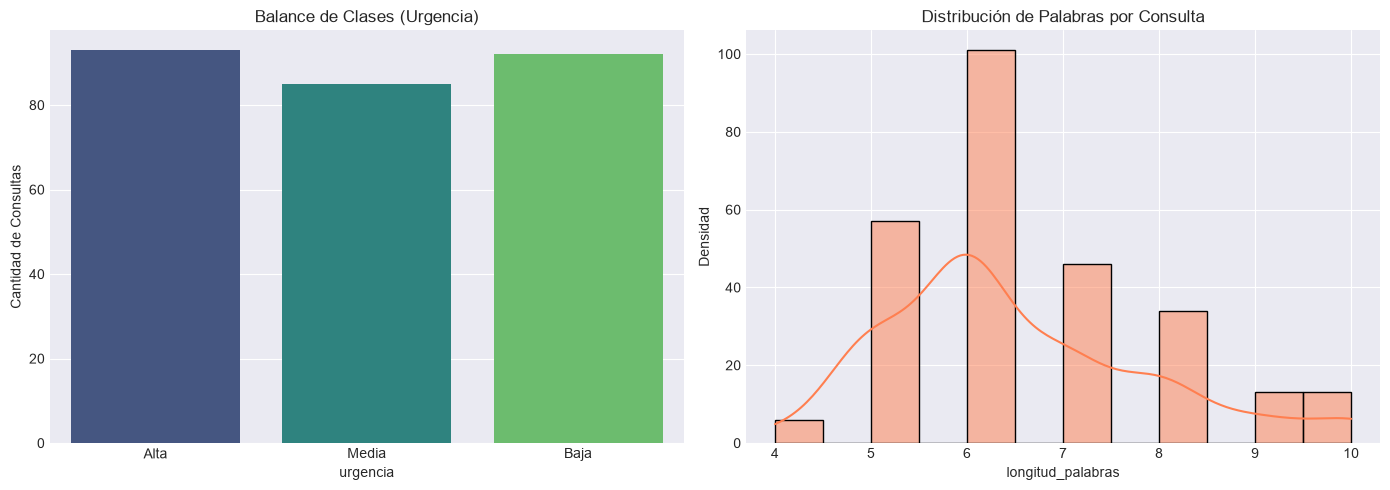

In [5]:
# ==========================================
# CELDA 5: Análisis Exploratorio Visual (EDA)
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Balance de Clases
sns.countplot(data=df_cejbot, x='urgencia', order=['Alta', 'Media', 'Baja'], palette='viridis', ax=axes[0])
axes[0].set_title('Balance de Clases (Urgencia)')
axes[0].set_ylabel('Cantidad de Consultas')

# Gráfico 2: Densidad de Longitud
sns.histplot(data=df_cejbot, x='longitud_palabras', bins=12, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Distribución de Palabras por Consulta')
axes[1].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

In [6]:
# ==========================================
# CELDA 6: Vectorización 
# ==========================================

# 1. División de datos (Train/Test Split estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    df_cejbot['consulta_limpia'], 
    df_cejbot['urgencia'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df_cejbot['urgencia']
)

# 2. Vectorización TF-IDF (Texto a Matriz Matemática)
vectorizador = TfidfVectorizer()
X_train_tfidf = vectorizador.fit_transform(X_train)
X_test_tfidf = vectorizador.transform(X_test)

# 3. Operaciones de Álgebra Lineal y Matrices
print("--- PROPIEDADES MATRICIALES ---")
print(f"Dimensiones de la Matriz de Entrenamiento: {X_train_tfidf.shape}")

# Producto punto de dos vectores 
v1 = X_train_tfidf[0].toarray()
v2 = X_train_tfidf[1].toarray()
similitud = np.dot(v1, v2.T)[0][0]
print(f"Producto punto entre vector 1 y 2: {similitud:.4f}")

--- PROPIEDADES MATRICIALES ---
Dimensiones de la Matriz de Entrenamiento: (216, 97)
Producto punto entre vector 1 y 2: 0.0000


In [7]:
# ==========================================
# CELDA 7: Entrenamiento, Benchmarking y Exportación
# ==========================================

# 1. Definición de algoritmos a evaluar
modelos = {
    "Naive Bayes": MultinomialNB(),
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42)
}

print("--- RENDIMIENTO DE MODELOS (BENCHMARKING) ---")
for nombre, modelo in modelos.items():
    modelo.fit(X_train_tfidf, y_train)
    precision = accuracy_score(y_test, modelo.predict(X_test_tfidf))
    print(f"Modelo {nombre}: {precision * 100:.2f}% de precisión")

# 2. Crear carpeta destino si no existe
carpeta_modelos = "modelos_exportados"
os.makedirs(carpeta_modelos, exist_ok=True)

# 3. Seleccionar el clasificador final (Regresión Logística)
clasificador_final = modelos["Regresión Logística"]

# 4. Definir nombres limpios de los artefactos
ruta_clasificador = os.path.join(carpeta_modelos, 'clasificador_lr.pkl')
ruta_vectorizador = os.path.join(carpeta_modelos, 'vectorizador_tfidf.pkl')

# 5. Guardar los archivos serializados
joblib.dump(clasificador_final, ruta_clasificador)
joblib.dump(vectorizador, ruta_vectorizador)

print("--- EXPORTACIÓN EXITOSA ---")
print(f"Clasificador guardado en: {ruta_clasificador}")
print(f"Vectorizador guardado en: {ruta_vectorizador}")

--- RENDIMIENTO DE MODELOS (BENCHMARKING) ---
Modelo Naive Bayes: 100.00% de precisión
Modelo Regresión Logística: 100.00% de precisión
Modelo Árbol de Decisión: 100.00% de precisión
--- EXPORTACIÓN EXITOSA ---
Clasificador guardado en: modelos_exportados\clasificador_lr.pkl
Vectorizador guardado en: modelos_exportados\vectorizador_tfidf.pkl
